LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

Personal Loan
EMI Free Loan
Personal Overdraft
Advance Salary Loan
This case study will focus on the underwriting process behind Personal Loan only

**Problem Statement:**

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

**Data dictionary:**

loan_amnt : The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
term : The number of payments on the loan. Values are in months and can be either 36 or 60.
int_rate : Interest Rate on the loan
installment : The monthly payment owed by the borrower if the loan originates.
grade : LoanTap assigned loan grade
sub_grade : LoanTap assigned loan subgrade
emp_title :The job title supplied by the Borrower when applying for the loan.*
emp_length : Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
home_ownership : The home ownership status provided by the borrower during registration or obtained from the credit report.
annual_inc : The self-reported annual income provided by the borrower during registration.
verification_status : Indicates if income was verified by LoanTap, not verified, or if the income source was verified
issue_d : The month which the loan was funded
loan_status : Current status of the loan - Target Variable
purpose : A category provided by the borrower for the loan request.
title : The loan title provided by the borrower
dti : A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LoanTap loan, divided by the borrower’s self-reported monthly income.
earliest_cr_line :The month the borrower's earliest reported credit line was opened
open_acc : The number of open credit lines in the borrower's credit file.
pub_rec : Number of derogatory public records
revol_bal : Total credit revolving balance
revol_util : Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
total_acc : The total number of credit lines currently in the borrower's credit file
initial_list_status : The initial listing status of the loan. Possible values are – W, F
application_type : Indicates whether the loan is an individual application or a joint application with two co-borrowers
mort_acc : Number of mortgage accounts.
pub_rec_bankruptcies : Number of public record bankruptcies
Address: Address of the individual

**Concept Used:**

Exploratory Data Analysis
Feature Engineering
Logistic Regression
Precision Vs Recall Tradeoff

Descriptive/Diagnostic
Import the Dataset: **bold text**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving logistic_regression.csv to logistic_regression.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/logistic_regression.csv")

df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


**Check dimensions:**

In [ ]:
df.shape

(396030, 27)

**Basic EDA**

Check data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

**Statistical summary**

In [ ]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


**Target Variable Analysis**

In [ ]:
df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


Percentage:

In [ ]:
df["loan_status"].value_counts(normalize=True) * 100

,proportion
loan_status,
Fully Paid,80.387092
Charged Off,19.612908


So the dataset is imbalanced.

This is very important.

It means:

If the model simply predicts "Fully Paid" for everyone, it can already achieve about 80% accuracy.

Therefore accuracy alone is not enough.

**Visualize Target**

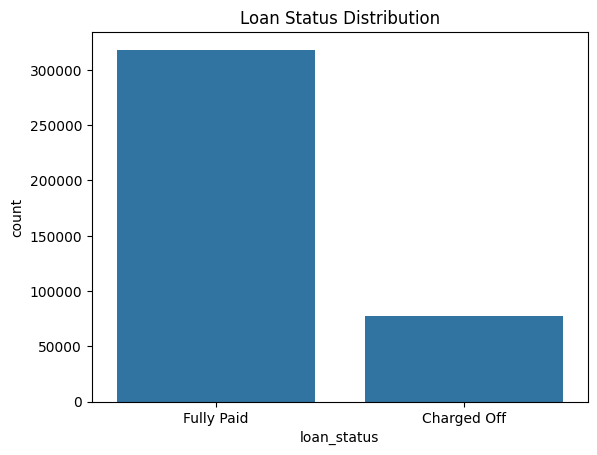

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.show()

Interpretation

There are considerably more fully-paid loans than charged-off loans.

Therefore the minority class, Charged Off, is especially important for risk detection.

**Missing Values**

In [ ]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


**Percentage:**

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_pct
}).sort_values("Percentage", ascending=False)

,Missing,Percentage
mort_acc,37795,9.543469
emp_title,22927,5.789208
emp_length,18301,4.621115
title,1756,0.443401
pub_rec_bankruptcies,535,0.135091
revol_util,276,0.069692
installment,0,0.000000
int_rate,0,0.000000
term,0,0.000000
grade,0,0.000000


**Duplicate Check**

In [ ]:
df.duplicated().sum()

np.int64(0)

Univariate Analysis

For numerical variables:

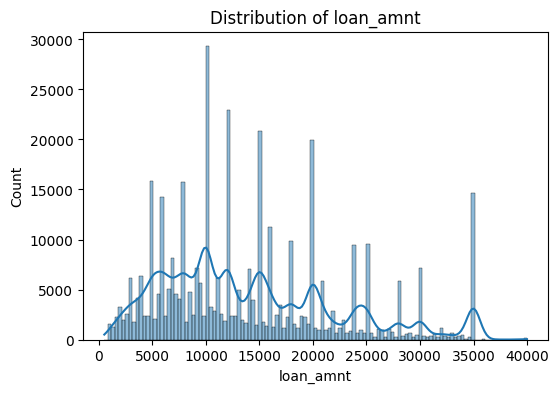

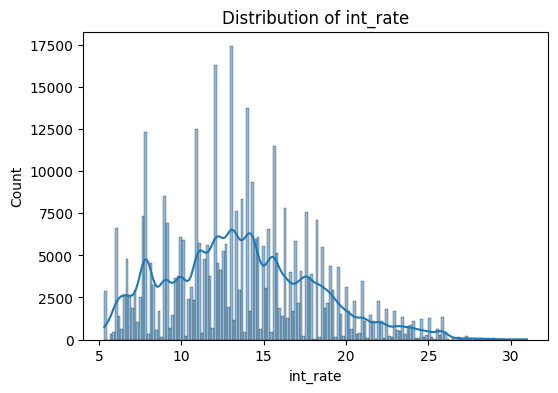

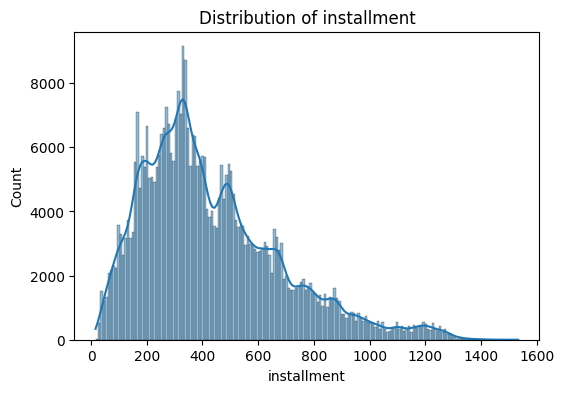

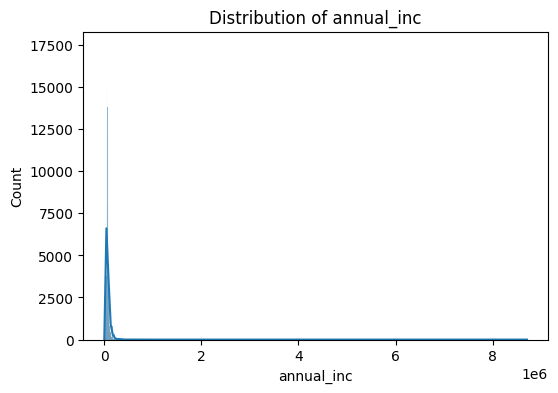

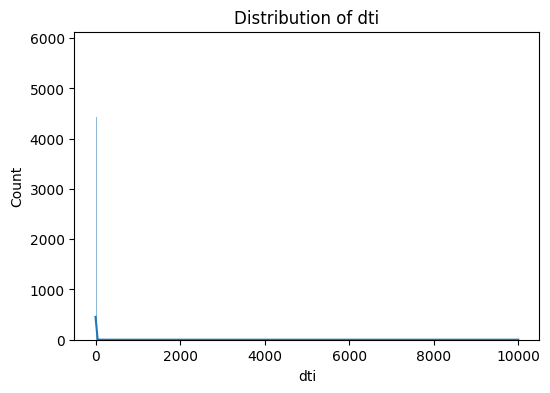

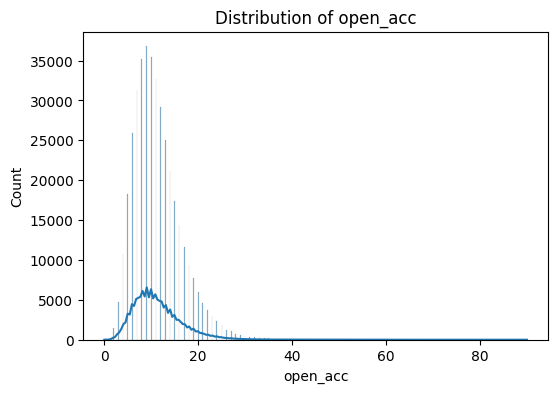

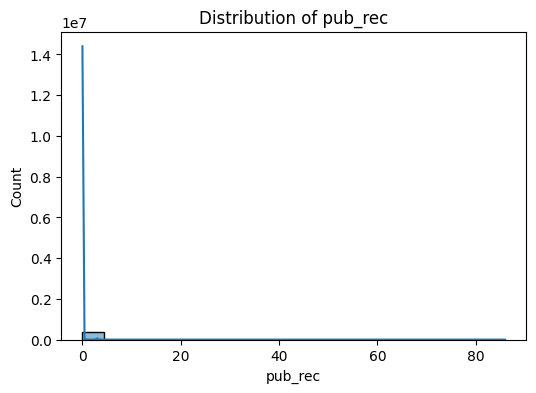

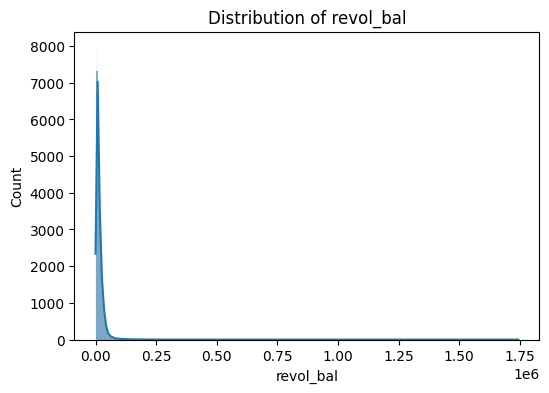

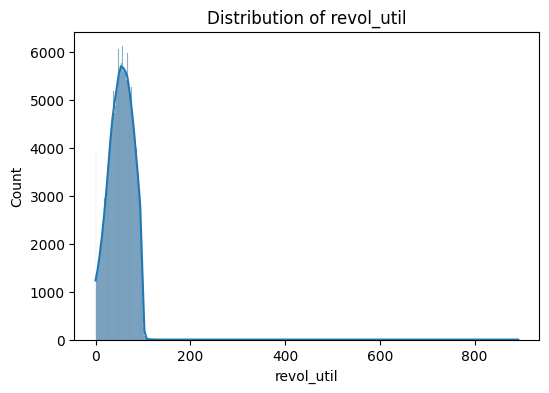

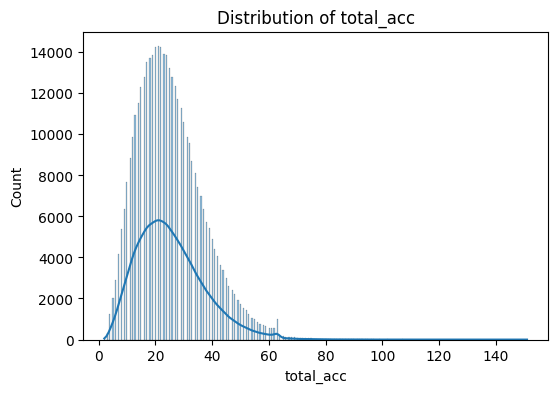

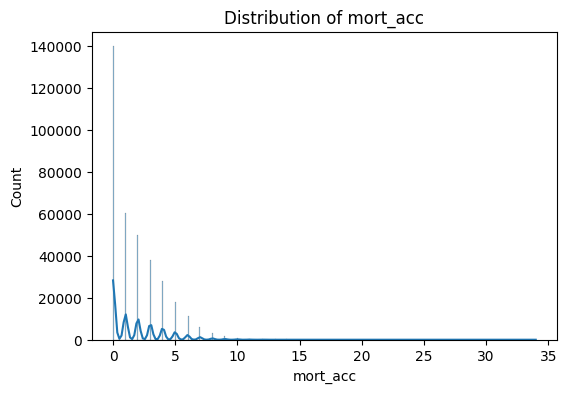

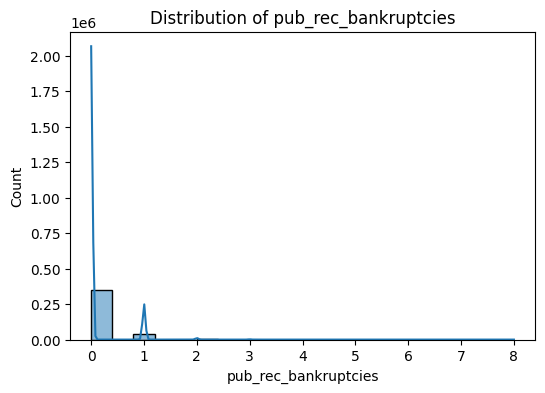

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

For categorical variables:

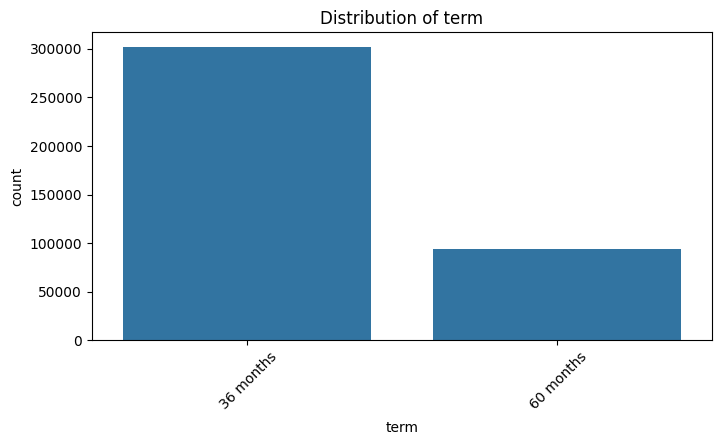

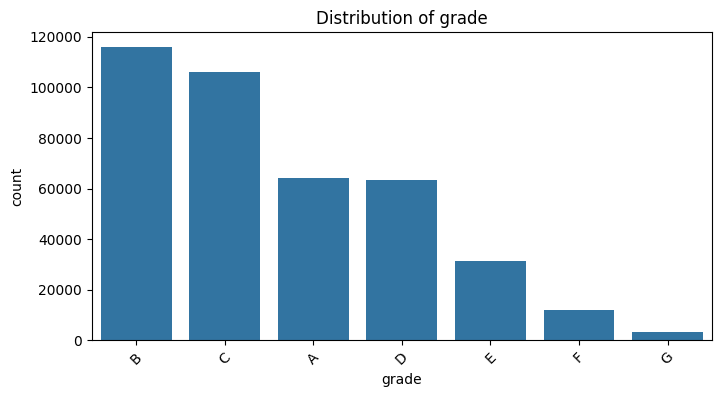

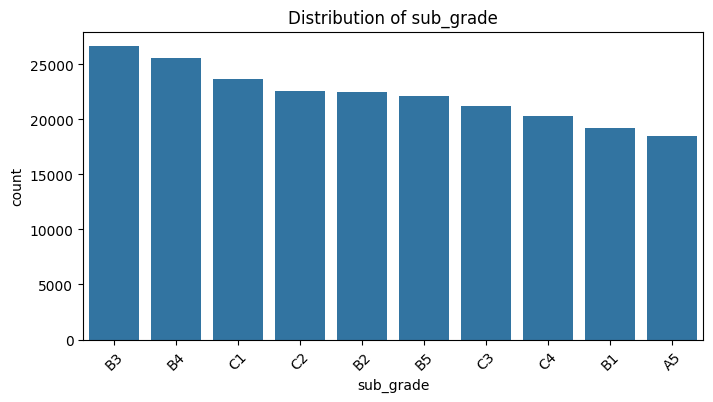

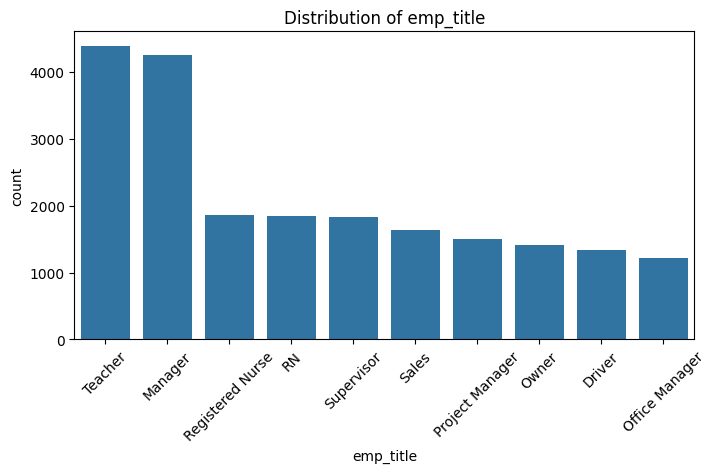

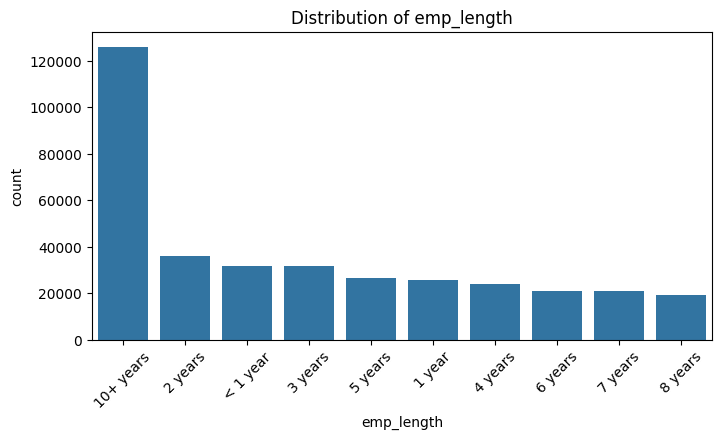

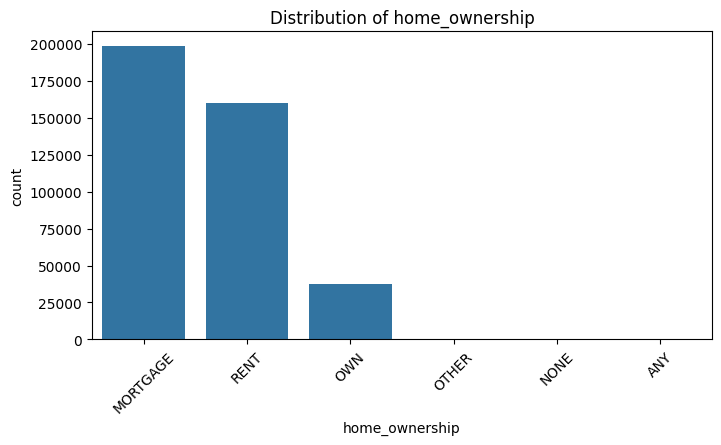

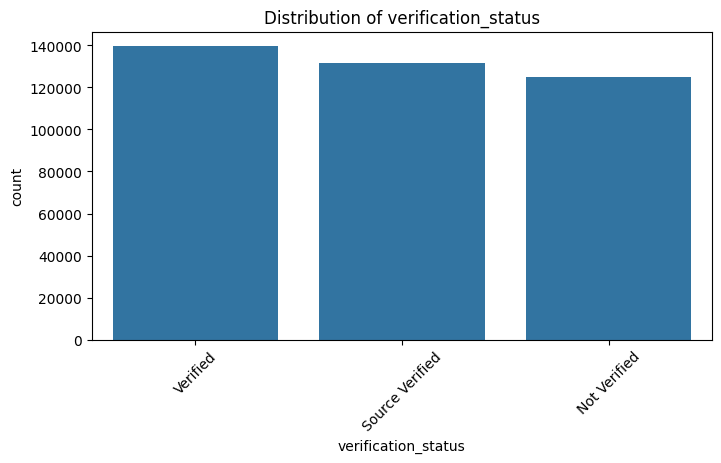

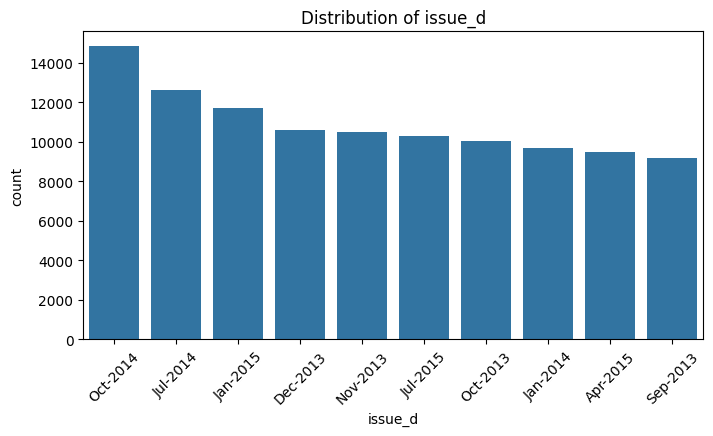

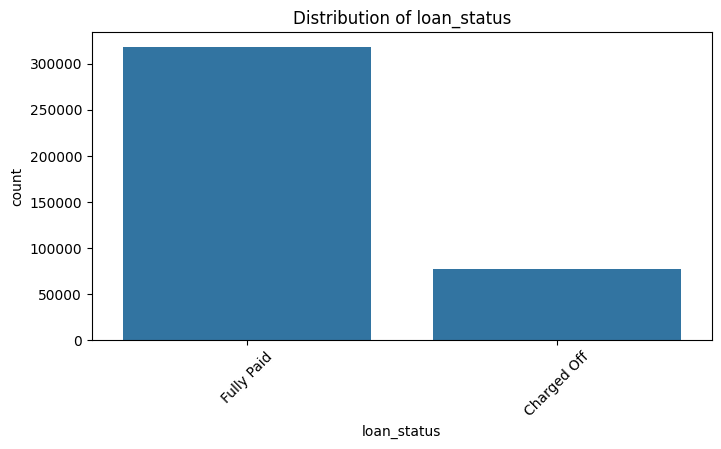

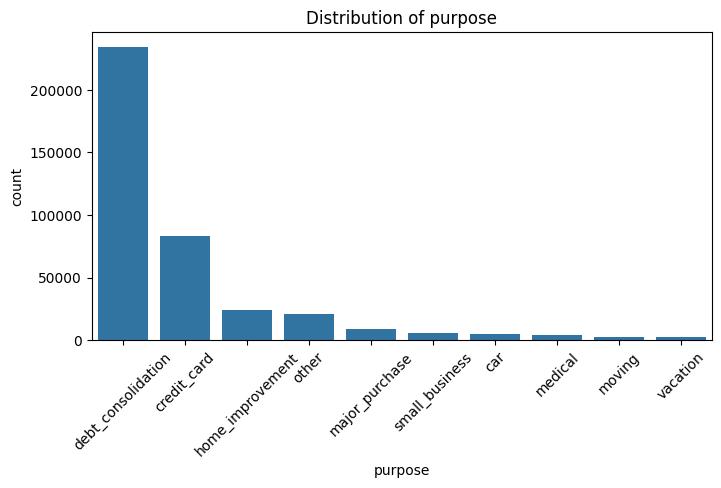

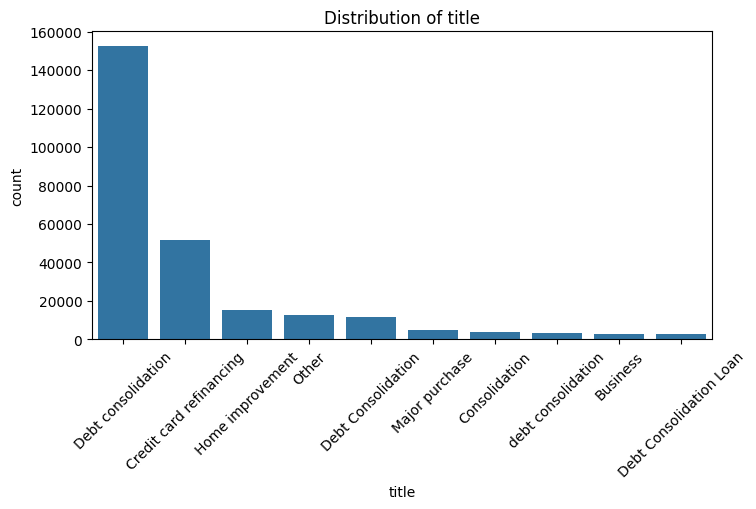

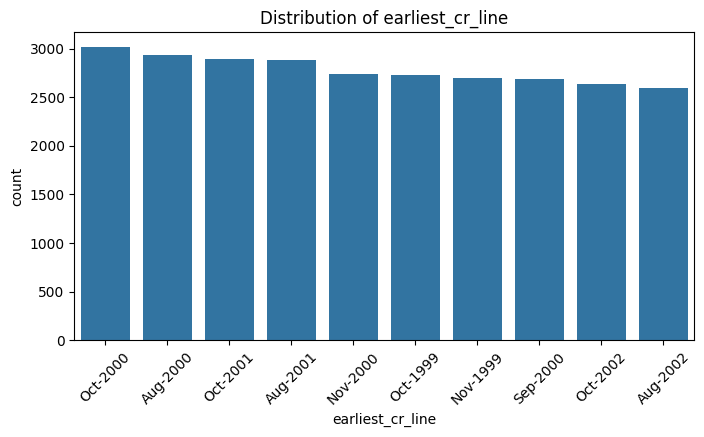

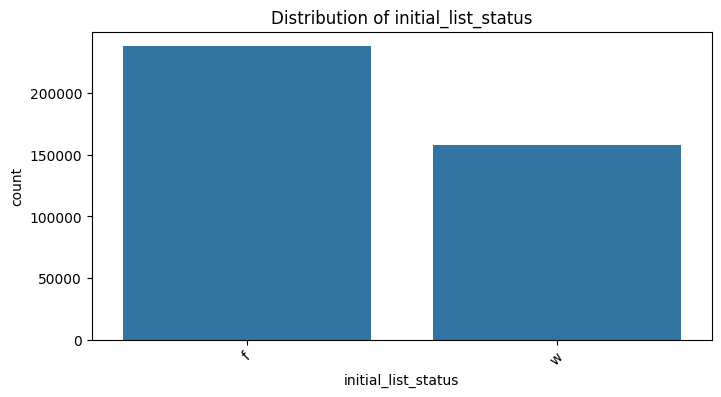

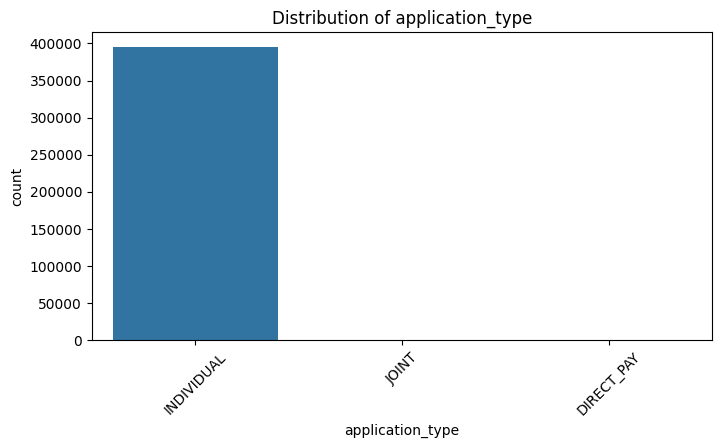

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


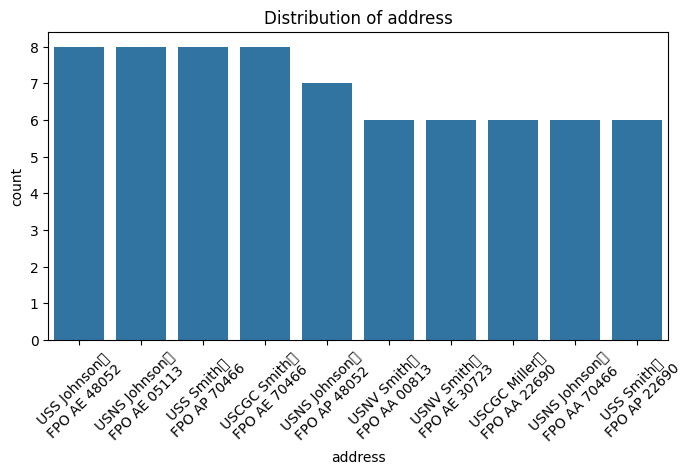

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().head(10).index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

**Important EDA Observations**
Home ownership

The majority of borrowers have:

MORTGAGE

This is also reported in analyses of this dataset.

The next major category is generally:

RENT

**Loan purpose**

The largest purpose is:

debt_consolidation

followed by:

credit_card

This is useful because debt consolidation is a major reason borrowers seek personal loans.

Loan term

There are only two terms:

36 months
60 months

The 36-month term is more common.

**Bivariate Analysis**

Now we want to answer:

How does each variable relate to loan repayment?

Loan Status vs Loan Amount

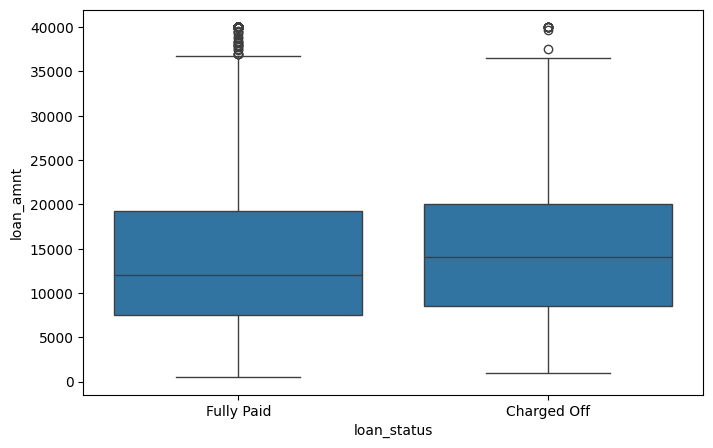

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_amnt"
)

plt.show()

The median loan amount is somewhat higher for charged-off loans in the dataset analysis.

This suggests:

Larger loans may be associated with somewhat greater default risk, although loan amount alone is not sufficient to predict default.

Loan Amount vs Installment

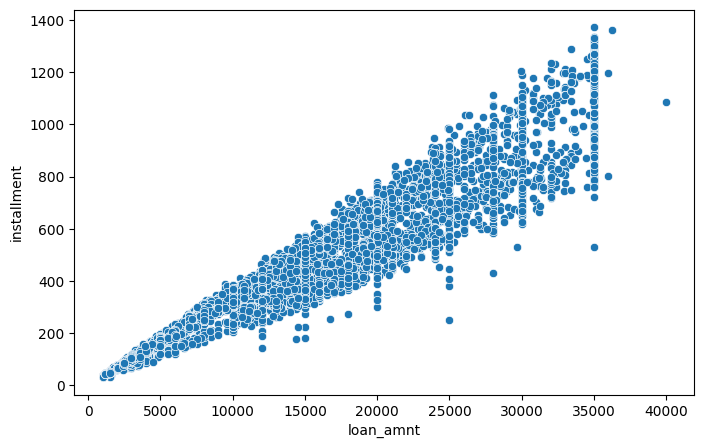

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(10000),
    x="loan_amnt",
    y="installment"
)

plt.show()

You will see a strong positive relationship.

As:

Loan Amount ↑
        ↓
Installment ↑

This makes intuitive sense.

If a person borrows ₹20,000 instead of ₹5,000, the monthly repayment will generally be higher.

Correlation

In [ ]:
df[["loan_amnt", "installment"]].corr()

,loan_amnt,installment
loan_amnt,1.000000,0.953929
installment,0.953929,1.000000


The correlation is very high and positive. Analyses of this dataset identify loan amount and installment as highly correlated.

Important concept

Correlation close to +1 means:

When loan_amnt increases, installment also tends to increase.

This creates a multicollinearity problem when both are used in Logistic Regression.

**Multicollinearity**

loan_amnt → installment  very strongly.
If we put both into Logistic Regression:

loan_status
     ↑
loan_amnt
installment
the model may struggle to determine the independent contribution of each variable.

We can check this using VIF — Variance Inflation Factor.
VIF values
loan_amnt     11.58
installment   11.04
indicates strong multicollinearity. After removing installment, the VIF of loan_amnt dropped substantially.
Therefore, I recommend:

Drop installment and retain loan_amnt.

**Feature Engineering**

Public records

In [ ]:
df["any_pub_rec"] = np.where(df["pub_rec"] > 0, 1, 0)

Mortgage account

In [ ]:
df["any_mort_acc"] = np.where(df["mort_acc"] > 0, 1, 0)

Bankruptcy

In [ ]:
df["any_bankruptcy"] = np.where(
    df["pub_rec_bankruptcies"] > 0,
    1,
    0
)

**Target Encoding**

In [ ]:
df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

I recommend using:

0 = Fully Paid
1 = Charged Off

because now:

Logistic Regression probability directly represents probability of default.

**Handle term**

Convert:

36 months → 36
60 months → 60

In [ ]:
df["term"] = df["term"].astype(int)

**Handle Employment Length**

Convert:
< 1 year → 0
10+ years → 10

In [ ]:
df["emp_length"] = (
    df["emp_length"]
    .str.replace(" years", "", regex=False)
    .str.replace(" year", "", regex=False)
    .str.replace("< 1", "0", regex=False)
    .str.replace("10+", "10", regex=False)
)

df["emp_length"] = pd.to_numeric(df["emp_length"])

For missing values:

In [ ]:
df["emp_length"] = df["emp_length"].fillna(
    df["emp_length"].median()
)

**Missing Value Treatment**

For numerical variables:

In [ ]:
num_missing = [
    "emp_length",
    "revol_util",
    "mort_acc",
    "pub_rec_bankruptcies"
]

for col in num_missing:
    df[col] = df[col].fillna(df[col].median())

For categorical variables:

In [ ]:
df["home_ownership"] = df["home_ownership"].fillna(
    df["home_ownership"].mode()[0]
)

For high-cardinality variables like emp_title:

It is usually better to drop the raw column for a basic Logistic Regression model rather than create hundreds of thousands of dummy variables.

Instead of feeding the complete address directly into Logistic Regression extract ZIP code.

In [ ]:
df["zip_code"] = df["address"].str[-5:]

But even ZIP code can introduce geographical/proxy effects, so it should be handled carefully.

In [ ]:
df.drop(columns=["address"], inplace=True)

**Drop High-Cardinality / Less Useful Variables**

For a clean baseline model:

In [ ]:
drop_cols = [
    "emp_title",
    "title",
    "issue_d",
    "earliest_cr_line",
    "sub_grade"
]

df.drop(columns=drop_cols, inplace=True)

emp_title

173,000+ unique values.

title

~48,000 unique values.

address

~393,700 unique values.

One-hot encoding these would create an enormous sparse feature matrix.

**Outlier Treatment**

This dataset has significant outliers.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

print(num_cols)

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
       'annual_inc', 'loan_status', 'dti', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
       'any_pub_rec', 'any_mort_acc', 'any_bankruptcy'],
      dtype='object')


Check outliers using IQR

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

loan_amnt : 191
term : 94025
int_rate : 3777
installment : 11250
emp_length : 0
annual_inc : 16700
loan_status : 77673
dti : 275
open_acc : 10307
pub_rec : 57758
revol_bal : 21259
revol_util : 12
total_acc : 8499
mort_acc : 6843
pub_rec_bankruptcies : 45115
any_pub_rec : 57758
any_mort_acc : 0
any_bankruptcy : 45115


annual_inc
dti
revol_bal
open_acc

have extreme observations.

However, there is an important point for a lending problem:

Cant blindly remove every statistical outlier.

A very high income person may genuinely exist.

A borrower with many credit accounts may genuinely exist.

So I would first investigate whether an outlier is:

genuine,
data-entry error,
impossible value.

Treat Outliers Using Capping

In [ ]:
outlier_cols = [
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies"
]

In [ ]:
for col in outlier_cols:

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

Extreme values were treated using percentile-based capping rather than deleting observations, because extreme income, loan amount, or credit values may represent genuine customers and deleting them could introduce selection bias

**Prepare X and y**

In [ ]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

Categorical variables need encoding.

In [ ]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

I used stratify=y

Because the target is imbalanced:

80% Fully Paid
20% Charged Off

We want approximately the same ratio in train and test.

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.fit_transform(X_train)

array([[ 0.03343216,  1.79147724,  0.37342491, ..., -0.40967538,
        -0.16875737, -0.16951753],
       [ 0.10522388,  1.79147724,  0.07805492, ..., -0.40967538,
        -0.16875737, -0.16951753],
       [-0.73234627, -0.55819855, -0.5663887 , ..., -0.40967538,
        -0.16875737, -0.16951753],
       ...,
       [-0.67251983, -0.55819855, -0.88861051, ...,  2.44095701,
        -0.16875737, -0.16951753],
       [-1.03147846, -0.55819855,  1.08499807, ..., -0.40967538,
        -0.16875737, -0.16951753],
       [ 0.94279403,  1.79147724,  0.86570823, ..., -0.40967538,
        -0.16875737,  5.89909502]])

In [ ]:
scaler.transform(X_test)

array([[-1.16608795, -0.55819855, -1.75681927, ..., -0.40967538,
        -0.16875737, -0.16951753],
       [-1.45026354, -0.55819855,  0.59271475, ..., -0.40967538,
        -0.16875737, -0.16951753],
       [-0.13408187, -0.55819855, -0.06963008, ..., -0.40967538,
        -0.16875737, -0.16951753],
       ...,
       [ 0.52400896,  1.79147724, -0.59324052, ..., -0.40967538,
         5.92566706, -0.16951753],
       [-1.11523548, -0.55819855, -0.03382765, ..., -0.40967538,
        -0.16875737, -0.16951753],
       [-0.22681285,  1.79147724,  2.31570637, ..., -0.40967538,
        -0.16875737, -0.16951753]])

We do not fit the scaler on test data.

Otherwise we introduce data leakage.

Logistic **Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

class_weight="balanced"
Because:

Fully Paid       ≈ 80%
Charged Off      ≈ 20%

The model needs to pay more attention to the minority class.

**Prediction**

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred

array([0, 0, 1, ..., 1, 1, 1])

**Probability:**

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_prob

array([1.75959186e-04, 1.37749219e-07, 6.36949918e-01, ...,
       9.99956197e-01, 5.68842054e-01, 8.32484535e-01])

y_prob gives:

Probability that the borrower belongs to class 1 = Charged Off.

**Confusion Matrix**

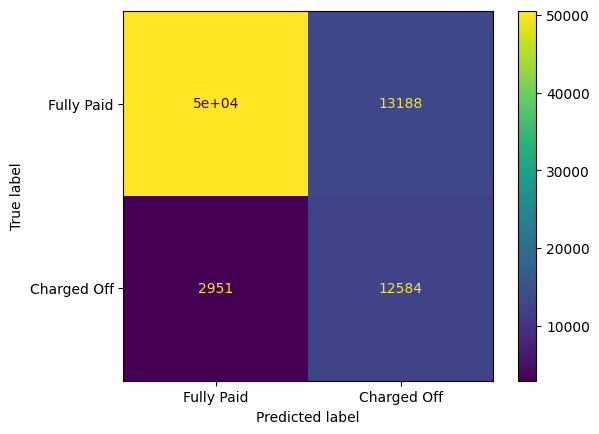

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fully Paid", "Charged Off"]
)

disp.plot()
plt.show()

The four outcomes are:

Actual Fully Paid	Actual Charged Off
Predicted Fully Paid	TN	FN
Predicted Charged Off	FP	TP

For the bank, these errors have different costs.

**Precision:**


Of all customers predicted as defaulters, how many actually defaulted?

High precision means:

When the model says "high risk", it is usually correct.



**Recall**

Of all actual defaulters, how many did we successfully detect?

This is extremely important for a bank.

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.4882818562781313
Recall: 0.8100418410041841


F1 Score

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6092914033940978


**Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fully Paid", "Charged Off"]
))

              precision    recall  f1-score   support

  Fully Paid       0.94      0.79      0.86     63671
 Charged Off       0.49      0.81      0.61     15535

    accuracy                           0.80     79206
   macro avg       0.72      0.80      0.74     79206
weighted avg       0.86      0.80      0.81     79206



Confusion Matrix

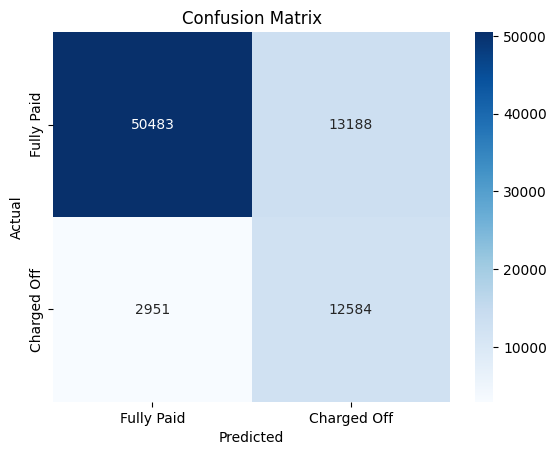

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fully Paid", "Charged Off"],
    yticklabels=["Fully Paid", "Charged Off"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Precision vs Recall Plot

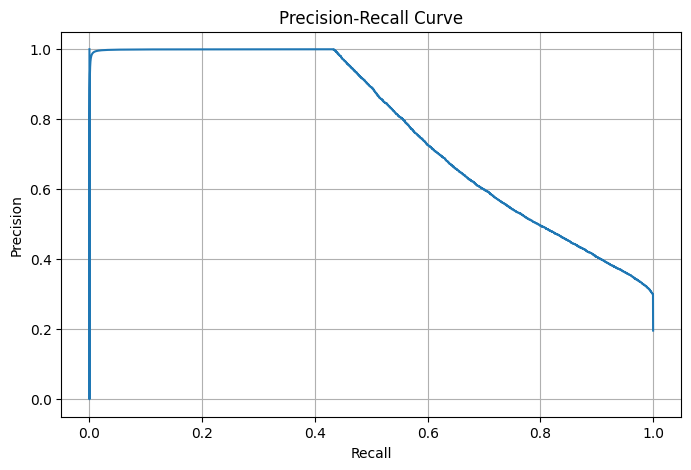

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid()
plt.show()

**ROC-AUC**

In [ ]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC:", auc_score)

ROC AUC: 0.9053912791768003


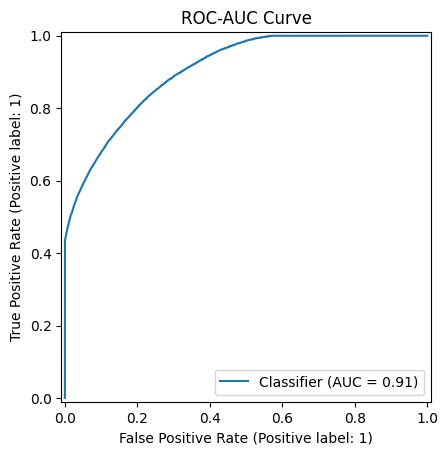

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC-AUC Curve")
plt.show()

**Interpretation**

ROC-AUC measures how well the model separates:

Fully Paid
       vs
Charged Off

**AUC:**

0.5 → random
1.0 → perfect

Higher is better.

**Precision-Recall Curve**

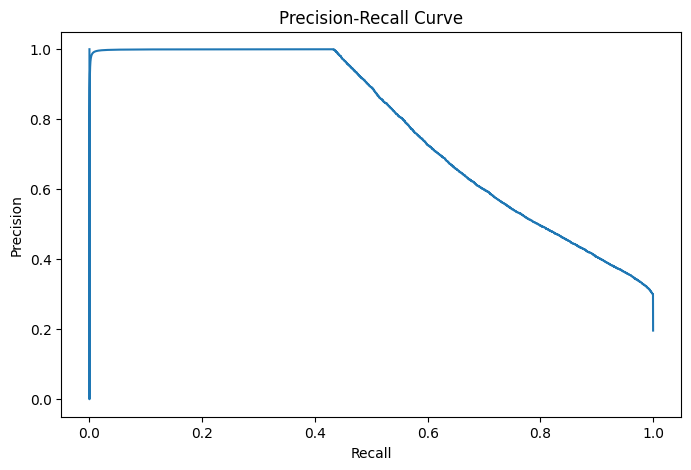

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

This is particularly useful here because the target class is imbalanced.

**Threshold**

In [ ]:
model.predict(X_test_scaled)

array([0, 0, 1, ..., 1, 1, 1])

In [ ]:
threshold = 0.30

y_pred_custom = (
    y_prob >= threshold
).astype(int)
y_pred_custom

array([0, 0, 1, ..., 1, 1, 1])

**Model Coefficients**

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df["Abs_Coefficient"] = (
    coef_df["Coefficient"].abs()
)

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df.head(20)

,Feature,Coefficient,Abs_Coefficient
54,zip_code_93700,3.114832,3.114832
47,zip_code_11650,3.086254,3.086254
53,zip_code_86630,3.047834,3.047834
52,zip_code_70466,2.797493,2.797493
50,zip_code_30723,2.784776,2.784776
51,zip_code_48052,2.781634,2.781634
48,zip_code_22690,2.780855,2.780855
49,zip_code_29597,-2.574756,2.574756
46,zip_code_05113,-2.570354,2.570354
6,dti,0.490108,0.490108


**Interpretation**

Because:

Target = 1 → Charged Off

positive coefficient

means:

Increasing that feature tends to increase the log-odds of default, holding other variables constant.

negative coefficient

means:

Increasing that feature tends to decrease the log-odds of default.

Logistic Regression Formula

In [ ]:
coef_df["Odds_Ratio"] = np.exp(
    coef_df["Coefficient"]
)
print(coef_df["Odds_Ratio"])

54    22.529649
47    21.894902
53    21.069661
52    16.403465
50    16.196193
51    16.145385
48    16.132805
49     0.076172
46     0.076508
6      1.632493
19     1.608074
18     1.566129
20     1.492717
21     1.301849
17     1.285163
1      1.265265
3      1.165082
22     1.161190
5      0.868859
31     1.142595
7      1.116133
11     0.900003
0      0.905622
40     1.094596
28     1.089131
30     1.086305
10     1.079707
33     1.078596
38     1.068657
23     0.937465
27     1.065615
16     0.939894
12     0.945275
9      0.949014
14     1.053113
29     1.043210
36     1.041732
35     1.039989
8      1.034455
37     1.031615
4      0.973707
41     1.023375
2      1.022956
45     0.977723
34     1.014312
39     1.013426
42     0.987186
44     1.012329
26     1.011859
32     1.009885
15     1.008340
13     1.007257
43     1.004191
24     1.003248
25     1.000958
Name: Odds_Ratio, dtype: float64


Q8. Which features heavily affected the outcome?

In [ ]:
coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
).head(15)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
54,zip_code_93700,3.114832,3.114832,22.529649
47,zip_code_11650,3.086254,3.086254,21.894902
53,zip_code_86630,3.047834,3.047834,21.069661
52,zip_code_70466,2.797493,2.797493,16.403465
50,zip_code_30723,2.784776,2.784776,16.196193
51,zip_code_48052,2.781634,2.781634,16.145385
48,zip_code_22690,2.780855,2.780855,16.132805
49,zip_code_29597,-2.574756,2.574756,0.076172
46,zip_code_05113,-2.570354,2.570354,0.076508
6,dti,0.490108,0.490108,1.632493


In [ ]:
!ls

logistic_regression.csv  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/LoanTap-Logistic Regression.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/LoanTap-Logistic Regression.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 35 image(s).
[NbConvertApp] Writing 1676895 bytes to /content/drive/MyDrive/Colab Notebooks/LoanTap-Logistic Regression.html
